# **Extending the model to include an external field of interactions**

This notebook presents the implementation of an external interaction field extension to the quantum protein folding model on a tetrahedral (FCC/diamond) lattice.

---

### External Field Extension

### Module Layout

| Module | Key Class | Purpose |
| :----- | :-------- | :------ |
| `src/particle/external_field.py` | `ExternalField` | Field data model with two modes |
| `src/builder/hamiltonian_builder.py` | `HamiltonianBuilder` | Integrate `H_field` into total Hamiltonian |
| `src/analysis/field_influence_analysis.py` | `FieldInfluenceAnalysis` | Orchestrate VQE comparisons & plots |

---

## Imports and Setup

In [1]:
import sys
import os
from pathlib import Path

current_dir = Path(os.getcwd())
project_root = current_dir.parent
project_src = project_root / "src"

if str(project_src) not in sys.path:
    sys.path.insert(0, str(project_src))

os.environ['MPLBACKEND'] = 'Agg'

import logging
logging.getLogger().setLevel(logging.WARNING)

from particle.external_field import ExternalField, FieldMode
from builder.hamiltonian_builder import HamiltonianBuilder
from interaction.hp_interaction import HPInteraction
from protein.protein import Protein
from contact.contact_map import ContactMap
from distance.distance_map import DistanceMap
from utils.qubit_utils import remove_unused_qubits
from enums import InteractionType
from constants import EMPTY_SIDECHAIN_PLACEHOLDER
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

print('Imports OK')
print(f'   Project src: {project_src}')

2026-05-30 14:19:13 [INFO ] | logger               - Logger and handlers initialized


Imports OK
   Project src: c:\repos\quantum-protein-folding\src


---
## **`ExternalField` class**

The `ExternalField` class models complex environment as an assignment of a real-valued energy to every lattice node.

### Two field modes

| Mode | Class constant | Description |
| :--- | :------------- | :---------- |
| `UNIFORM` | `FieldMode.UNIFORM` | Every lattice node has the **same** energy `λ`. Useful for global bias tests. |
| `NON_UNIFORM` | `FieldMode.NON_UNIFORM` | Explicit `{coords -> energy}` mapping. Nodes absent from the map fall back to `default_energy` (default `0.0`). |

```python
# Uniform: every node returns -1.0
field = ExternalField.uniform(strength=-1.0)

# Non-uniform: only listed coords are special
field = ExternalField.non_uniform(
    energy_map={(0,): -2.0, (3,): -0.5},
    default_energy=0.0,
)
```
---

In [2]:
# create uniform field and demonstrate behavior
uniform_field = ExternalField.uniform(strength=-1.0)
print('=== Uniform Field ===')
print(repr(uniform_field))
print(f'  get_energy((0,))    -> {uniform_field.get_energy((0,))}')
print(f'  get_energy((3,))    -> {uniform_field.get_energy((3,))}')
print(f'  get_energy((99,99)) -> {uniform_field.get_energy((99, 99))}')
print(f'  nodes()             -> {uniform_field.nodes()}  (empty: default covers all)')

# demonstrate that set_energy can override specific nodes without affecting others
uniform_field.set_energy((2,), -3.5)
print(f'\nAfter set_energy((2,), -3.5):')
print(f'  get_energy((2,))    -> {uniform_field.get_energy((2,))}  <- overridden')
print(f'  get_energy((3,))    -> {uniform_field.get_energy((3,))}  <- unchanged')
print(f'  nodes()             -> {uniform_field.nodes()}')
print()

# create non-uniform field with a Gaussian profile and demonstrate behavior
chain_len = 5
mid = (chain_len - 1) / 2.0
sigma = max(chain_len / 4.0, 1.0)
lambda_max = -1.0
energy_map = {
    (i,): lambda_max * float(np.exp(-((i - mid) ** 2) / sigma**2))
    for i in range(chain_len)
}

nu_field = ExternalField.non_uniform(energy_map, default_energy=0.0)
print('=== Non-Uniform Field (Gaussian) ===')
print(repr(nu_field))
for i in range(chain_len):
    print(f'  get_energy(({i},))   -> {nu_field.get_energy((i,)):.4f}')
print(f'  get_energy((99,))   -> {nu_field.get_energy((99,))}  <- default (not in map)')
print()

2026-05-30 14:19:14 [DEBUG] | external_field       - Creating uniform ExternalField with strength=-1.0
2026-05-30 14:19:14 [INFO ] | external_field       - ExternalField created [mode=UNIFORM, explicit_nodes=0, default_energy=-1.0]
2026-05-30 14:19:14 [DEBUG] | external_field       - ExternalField.get_energy((0,)) -> -1.0
2026-05-30 14:19:14 [DEBUG] | external_field       - ExternalField.get_energy((3,)) -> -1.0
2026-05-30 14:19:14 [DEBUG] | external_field       - ExternalField.get_energy((99, 99)) -> -1.0
2026-05-30 14:19:14 [DEBUG] | external_field       - ExternalField: set energy at (2,) -> -3.5
2026-05-30 14:19:14 [DEBUG] | external_field       - ExternalField.get_energy((2,)) -> -3.5
2026-05-30 14:19:14 [DEBUG] | external_field       - ExternalField.get_energy((3,)) -> -1.0
2026-05-30 14:19:14 [DEBUG] | external_field       - Creating non-uniform ExternalField with 5 explicit node(s), default_energy=0.0
2026-05-30 14:19:14 [INFO ] | external_field       - ExternalField created [m

=== Uniform Field ===
ExternalField(mode=UNIFORM, explicit_nodes=0, default_energy=-1.0)
  get_energy((0,))    -> -1.0
  get_energy((3,))    -> -1.0
  get_energy((99,99)) -> -1.0
  nodes()             -> {}  (empty: default covers all)

After set_energy((2,), -3.5):
  get_energy((2,))    -> -3.5  <- overridden
  get_energy((3,))    -> -1.0  <- unchanged
  nodes()             -> {(2,): -3.5}

=== Non-Uniform Field (Gaussian) ===
ExternalField(mode=NON_UNIFORM, explicit_nodes=5, default_energy=0.0)
  get_energy((0,))   -> -0.0773
  get_energy((1,))   -> -0.5273
  get_energy((2,))   -> -1.0000
  get_energy((3,))   -> -0.5273
  get_energy((4,))   -> -0.0773
  get_energy((99,))   -> 0.0  <- default (not in map)



### **Visualizing field profiles**

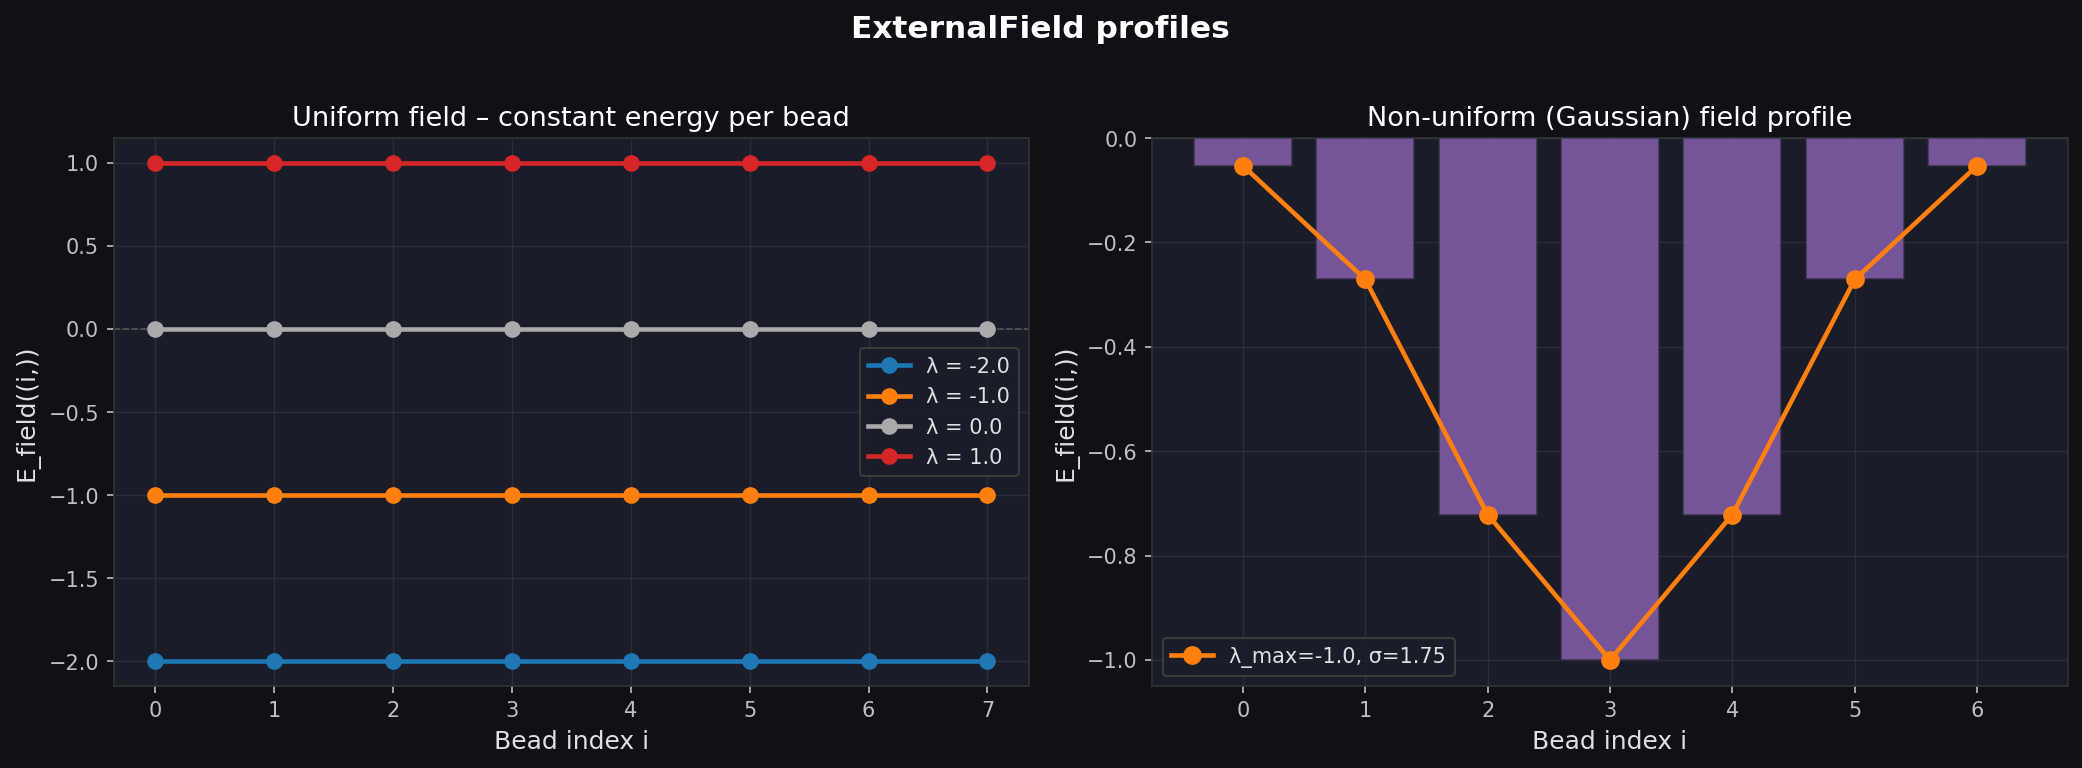

Figure saved -> plots/field_profiles.png


In [3]:
from IPython.display import Image, display
import os
os.makedirs('plots', exist_ok=True)

bead_indices = np.arange(8)

fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0f1117')

ax_left.set_facecolor('#1a1d27')
lambdas_to_show = [-2.0, -1.0, 0.0, 1.0]
palette = ['#1f77b4', '#ff7f0e', '#aaaaaa', '#d62728']
for lam, col in zip(lambdas_to_show, palette):
    energies = [lam] * len(bead_indices)
    ax_left.plot(bead_indices, energies, 'o-', color=col, linewidth=2.2,
                 markersize=7, label=f'λ = {lam}', zorder=3)

ax_left.axhline(0, color='#555', linewidth=0.8, linestyle='--')
ax_left.set_xlabel('Bead index i', fontsize=12, color='#e0e0e0')
ax_left.set_ylabel('E_field((i,))', fontsize=12, color='#e0e0e0')
ax_left.set_title('Uniform field – constant energy per bead', fontsize=13, color='#ffffff')
ax_left.tick_params(colors='#c0c0c0')
ax_left.grid(True, color='#2a2d3a', linewidth=0.7, zorder=0)
ax_left.spines[:].set_edgecolor('#333')
ax_left.set_xticks(bead_indices)
ax_left.legend(fontsize=10, facecolor='#1a1d27', edgecolor='#444', labelcolor='#e0e0e0')

ax_right.set_facecolor('#1a1d27')
chain_len_r = 7
mid_r = (chain_len_r - 1) / 2
sigma_r = chain_len_r / 4
lam_max_r = -1.0
bi_r = np.arange(chain_len_r)
fe_r = lam_max_r * np.exp(-((bi_r - mid_r)**2) / sigma_r**2)

ax_right.bar(bi_r, fe_r, color='#9467bd', edgecolor='#2a2d3a', linewidth=0.8, zorder=3, alpha=0.75)
ax_right.plot(bi_r, fe_r, 'o-', color='#ff7f0e', linewidth=2.2, markersize=8, zorder=4,
              label=f'λ_max={lam_max_r}, σ={sigma_r:.2f}')
ax_right.axhline(0, color='#555', linewidth=0.8, linestyle='--')
ax_right.set_xlabel('Bead index i', fontsize=12, color='#e0e0e0')
ax_right.set_ylabel('E_field((i,))', fontsize=12, color='#e0e0e0')
ax_right.set_title('Non-uniform (Gaussian) field profile', fontsize=13, color='#ffffff')
ax_right.tick_params(colors='#c0c0c0')
ax_right.grid(True, color='#2a2d3a', linewidth=0.7, zorder=0)
ax_right.spines[:].set_edgecolor('#333')
ax_right.set_xticks(bi_r)
ax_right.legend(fontsize=10, facecolor='#1a1d27', edgecolor='#444', labelcolor='#e0e0e0')

fig.suptitle('ExternalField profiles', fontsize=15,
             color='#ffffff', y=1.02, fontweight='bold')
fig.tight_layout()
plt.savefig('plots/field_profiles.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.close(fig)
display(Image('plots/field_profiles.png'))
print('Figure saved -> plots/field_profiles.png')

---
## **HamiltonianBuilder integration**

### Extended Hamiltonian formula

The total Hamiltonian now consists of three terms:

$$
H_{total} = H_{backbone} + H_{backtrack} + H_{field}
$$

| Term | Source | Description |
| :--- | :----- | :---------- |
| $H_{backbone}$ | `_build_backbone_contact_term()` | BB–BB interaction energy + overlap penalties |
| $H_{backtrack}$ | `_add_backtracking_penalty()` | Penalty for 180° turns in the main chain |
| $H_{field}$ | `_build_external_field_term()` | **External field bias** |

### Field term explanation

Our implementation maps each bead's sequential index `i` to a **1-tuple** `(i,)` as its lattice key:

$$
H_{field} = \sum_{i=0}^{N-1} E_{field}\bigl((i,)\bigr) \cdot \mathbf{I}
$$

This is a **scalar bias** proportional to the identity operator. For a uniform field with strength $\lambda$:

$$
H_{field}^{\text{uniform}} = \lambda \cdot N \cdot \mathbf{I}
$$

---

In [4]:
SEQUENCE = 'HPPHH'
interaction = HPInteraction()
side_chain = EMPTY_SIDECHAIN_PLACEHOLDER * len(SEQUENCE)

protein = Protein(
    main_protein_sequence=SEQUENCE,
    side_protein_sequence=side_chain,
    valid_symbols=interaction.valid_symbols,
)
contact_map = ContactMap(protein=protein)
distance_map = DistanceMap(protein=protein)

print(f'Protein sequence: {SEQUENCE}  (N = {len(SEQUENCE)} beads)')
print(f'HP model valid symbols: {interaction.valid_symbols}')
print()

def build_h(field=None, label=''):
    builder = HamiltonianBuilder(
        protein=protein,
        interaction=interaction,
        distance_map=distance_map,
        contact_map=contact_map,
        external_field=field,
    )
    h = builder.sum_hamiltonians()
    print(f'  {label:<30s}  num_qubits = {h.num_qubits:>3d},  num_paulis = {len(h):>5d}')
    return h

print('Building Hamiltonians for HPPHH:')
H_no_field   = build_h(field=None,                               label='H_no_field')
H_uniform    = build_h(field=ExternalField.uniform(-1.0),        label='H_uniform (λ=-1.0)')
nu_map_small = {(i,): -0.5 * float(np.exp(-i/2)) for i in range(len(SEQUENCE))}
H_nonuniform = build_h(field=ExternalField.non_uniform(nu_map_small), label='H_nonuniform')

print()
print('All three Hamiltonians built successfully')

2026-05-30 14:19:14 [DEBUG] | hp_interaction       - Initializing HPInteraction...
2026-05-30 14:19:14 [INFO ] | hp_interaction       - Successfully loaded 10 hydrophobic and 10 polar symbols from HP matrix at: c:\repos\quantum-protein-folding\src\resources\hp_matrix.txt
2026-05-30 14:19:14 [INFO ] | hp_interaction       - HPInteraction initialized with 20 valid amino acid symbols
2026-05-30 14:19:14 [DEBUG] | main_chain           - Initializing MainChain based from protein sequence: HPPHH...
2026-05-30 14:19:14 [INFO ] | bead                 - Initialized 2 turn qubits for Bead H (index: 0)
2026-05-30 14:19:14 [INFO ] | bead                 - Initialized 2 turn qubits for Bead P (index: 1)
2026-05-30 14:19:14 [INFO ] | bead                 - Initialized 2 turn qubits for Bead P (index: 2)
2026-05-30 14:19:14 [INFO ] | bead                 - Initialized 2 turn qubits for Bead H (index: 3)
2026-05-30 14:19:14 [INFO ] | bead                 - Initialized 0 turn qubits for Bead H (index: 

Protein sequence: HPPHH  (N = 5 beads)
HP model valid symbols: {'M', 'H', 'Q', 'A', 'V', 'Y', 'K', 'C', 'E', 'D', 'T', 'N', 'L', 'F', 'W', 'P', 'G', 'I', 'S', 'R'}

Building Hamiltonians for HPPHH:
  H_no_field                      num_qubits =  24,  num_paulis =     4
  H_uniform (λ=-1.0)              num_qubits =  24,  num_paulis =     4


2026-05-30 14:19:15 [DEBUG] | external_field       - ExternalField.get_energy((3,)) -> -0.11156508007421491
2026-05-30 14:19:15 [DEBUG] | hamiltonian_builder  - Bead H (index=3): field energy = -0.11156508007421491
2026-05-30 14:19:15 [DEBUG] | external_field       - ExternalField.get_energy((4,)) -> -0.06766764161830635
2026-05-30 14:19:15 [DEBUG] | hamiltonian_builder  - Bead H (index=4): field energy = -0.06766764161830635
2026-05-30 14:19:15 [INFO ] | hamiltonian_builder  - Finished building H_field: total field energy = -1.1664377721345591 over 5 beads.
2026-05-30 14:19:15 [DEBUG] | hamiltonian_builder  - No ligand provided – H_ligand set to zero identity (24 qubits).
2026-05-30 14:19:15 [DEBUG] | hamiltonian_builder  - Target qubits count for the final hamiltonian to be padded to: 24
2026-05-30 14:19:15 [DEBUG] | qubit_utils          - Padding operator from 8 to 24 qubits.
2026-05-30 14:19:15 [DEBUG] | qubit_utils          - Padding operator from 8 to 24 qubits.
2026-05-30 14:19:

  H_nonuniform                    num_qubits =  24,  num_paulis =     4

All three Hamiltonians built successfully


In [5]:
N = len(SEQUENCE)
lam = -1.0

diff = (H_uniform - H_no_field).simplify()

print(f'Physics verification for sequence "{SEQUENCE}" (N={N}, λ={lam}):')
print(f'  Expected shift:  N × λ = {N} × {lam} = {N * lam}')
print()

# The difference should reduce to a single identity term
pauli_labels = [str(p.paulis[0]) for p in diff]
pauli_coeffs = [complex(p.coeffs[0]).real for p in diff]
identity_terms = [
    (lbl, coeff) for lbl, coeff in zip(pauli_labels, pauli_coeffs)
    if set(lbl) <= {'I'}
]

if identity_terms:
    total_identity_coeff = sum(c for _, c in identity_terms)
    print(f'  Identity coefficient in (H_uniform - H_no_field): {total_identity_coeff:.6f}')
    if abs(total_identity_coeff - N * lam) < 1e-9:
        print(f'   VERIFIED: shift = {total_identity_coeff:.4f} = N×λ = {N*lam}')
    else:
        print(f'    Shift = {total_identity_coeff:.6f}, expected {N*lam}')
else:
    # Try summing all terms (might be combined in simplify)
    total_coeff = sum(pauli_coeffs)
    print(f'  Total coefficient sum in difference: {total_coeff:.6f}')
    print(f'  Expected: {N * lam}')
    if abs(total_coeff - N * lam) < 1e-9:
        print(f'   VERIFIED: shift = N×λ = {N*lam}')

print()
print('Summary:')
print(f'  (H_uniform - H_no_field)  ≡  {N} × ({lam}) × I  =  {N*lam:.1f} × I')
print('  This is a pure global energy shift - no change in eigenvector structure.')

Physics verification for sequence "HPPHH" (N=5, λ=-1.0):
  Expected shift:  N × λ = 5 × -1.0 = -5.0

  Identity coefficient in (H_uniform - H_no_field): -5.000000
   VERIFIED: shift = -5.0000 = N×λ = -5.0

Summary:
  (H_uniform - H_no_field)  ≡  5 × (-1.0) × I  =  -5.0 × I
  This is a pure global energy shift - no change in eigenvector structure.


---
## **`FieldInfluenceAnalysis` class**

### Experiment design

For a given protein sequence, the class runs VQE for:

1. **Baseline** - no external field (`external_field=None`)
2. **Uniform sweep** - one run per `λ` in `uniform_lambdas`
3. **Non-uniform (Gaussian)** - Gaussian-profiled field centred on the chain midpoint

### `ScenarioResult` dataclass

Each scenario's output is stored in a `ScenarioResult`:

```python
@dataclasses.dataclass
class ScenarioResult:
    label: str                           # e.g. "λ=1.0 (uniform)"
    field: ExternalField | None          # the field used
    minimum_energy: float                # VQE ground state energy
    best_bitstring: str                  # optimal turn-qubit state
    state_probabilities: dict[str, float]  # bitstring -> probability
    vqe_iterations: list[int]            # callback eval counts
    vqe_energies: list[float]            # callback energy values
```

---

In [6]:
from analysis.field_influence_analysis import FieldInfluenceAnalysis
from pathlib import Path
import time

analysis = FieldInfluenceAnalysis(
    main_chain='APRLRFY',
    interaction_type=InteractionType.MJ,
    uniform_lambdas=[0.1, 0.5, 1.0, 2.0],
    vqe_max_iter=50,
)

print('FieldInfluenceAnalysis created:')
print(f'  chain           = {analysis.main_chain}')
print(f'  interaction     = {analysis.interaction_type.name}')
print(f'  uniform_lambdas = {analysis.uniform_lambdas}')
print(f'  vqe_max_iter    = {analysis.vqe_max_iter}')
print()
print('Running VQE for all field scenarios...')
print()

t0 = time.time()
analysis.run()
elapsed = time.time() - t0

print(f'Done in {elapsed:.1f} s  ({elapsed/60:.1f} min)')
print()
print(analysis.summary())

2026-05-30 14:19:16 [DEBUG] | mj_interaction       - Initializing MJInteraction...
2026-05-30 14:19:16 [INFO ] | mj_interaction       - Successfully loaded 400 energy pairs from MJ matrix at: c:\repos\quantum-protein-folding\src\resources\mj_matrix.txt
2026-05-30 14:19:16 [INFO ] | mj_interaction       - MJInteraction initialized with 20 valid amino acid symbols
2026-05-30 14:19:16 [DEBUG] | main_chain           - Initializing MainChain based from protein sequence: APRLRFY...
2026-05-30 14:19:16 [INFO ] | bead                 - Initialized 2 turn qubits for Bead A (index: 0)
2026-05-30 14:19:16 [INFO ] | bead                 - Initialized 2 turn qubits for Bead P (index: 1)
2026-05-30 14:19:16 [INFO ] | bead                 - Initialized 2 turn qubits for Bead R (index: 2)
2026-05-30 14:19:16 [INFO ] | bead                 - Initialized 2 turn qubits for Bead L (index: 3)
2026-05-30 14:19:16 [INFO ] | bead                 - Initialized 2 turn qubits for Bead R (index: 4)
2026-05-30 14:

FieldInfluenceAnalysis created:
  chain           = APRLRFY
  interaction     = MJ
  uniform_lambdas = [0.1, 0.5, 1.0, 2.0]
  vqe_max_iter    = 50

Running VQE for all field scenarios...



2026-05-30 14:19:17 [INFO ] | field_influence_analysis - Scenario 'baseline (no field)' complete: E_min=-1.425000, best_state=011000101
2026-05-30 14:19:17 [INFO ] | field_influence_analysis - --- Scenario: lambda=0.1 (uniform) ---
2026-05-30 14:19:17 [DEBUG] | external_field       - Creating uniform ExternalField with strength=0.1
2026-05-30 14:19:17 [INFO ] | external_field       - ExternalField created [mode=UNIFORM, explicit_nodes=0, default_energy=0.1]
2026-05-30 14:19:17 [DEBUG] | hamiltonian_builder  - Started process of building total hamiltonian...
2026-05-30 14:19:17 [DEBUG] | hamiltonian_builder  - Creating hamiltonian term of backbone-backbone (BB-BB) contacts...
2026-05-30 14:19:17 [DEBUG] | hamiltonian_builder  - Adding backbone-backbone contact between Bead (index 0) and Bead (index 5) [1st neighbor contact]
2026-05-30 14:19:17 [DEBUG] | hamiltonian_builder  - Adding backbone-backbone contact between Bead (index 1) and Bead (index 5) [2nd neighbor contact]
2026-05-30 14:

Done in 4.7 s  (0.1 min)

Scenario                             E_min  Best bitstring
----------------------------------------------------------
baseline (no field)              -1.425000  011000101
lambda=0.1 (uniform)             -0.725000  010100101
lambda=0.5 (uniform)              2.075000  010100101
lambda=1.0 (uniform)              5.575000  011000101
lambda=2.0 (uniform)             12.575000  011000101
non-uniform (centre boost)       -4.515442  010100101


2026-05-30 14:19:21 [INFO ] | field_influence_analysis - Saved plot: plots\energy_vs_lambda.png
2026-05-30 14:19:21 [INFO ] | field_influence_analysis - Saved plot: plots\energy_comparison_bar.png
2026-05-30 14:19:22 [INFO ] | field_influence_analysis - Saved plot: plots\probability_distributions.png
2026-05-30 14:19:22 [INFO ] | field_influence_analysis - All plots saved to plots


Figure 1: Energy vs. uniform field strength λ


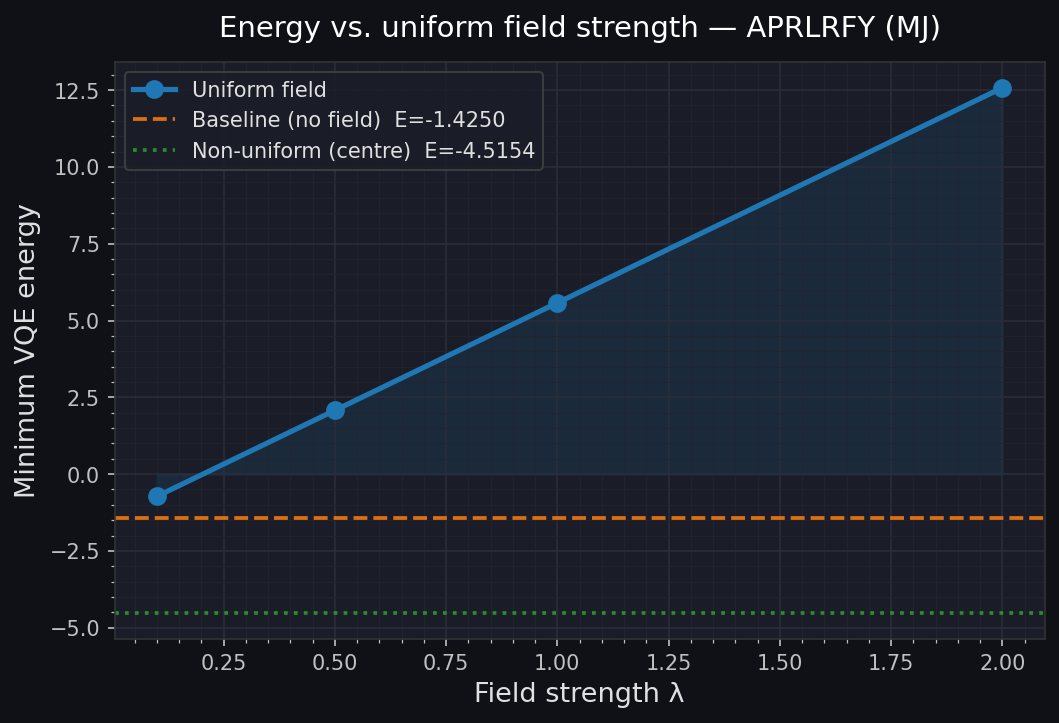


Figure 2: Energy comparison bar chart


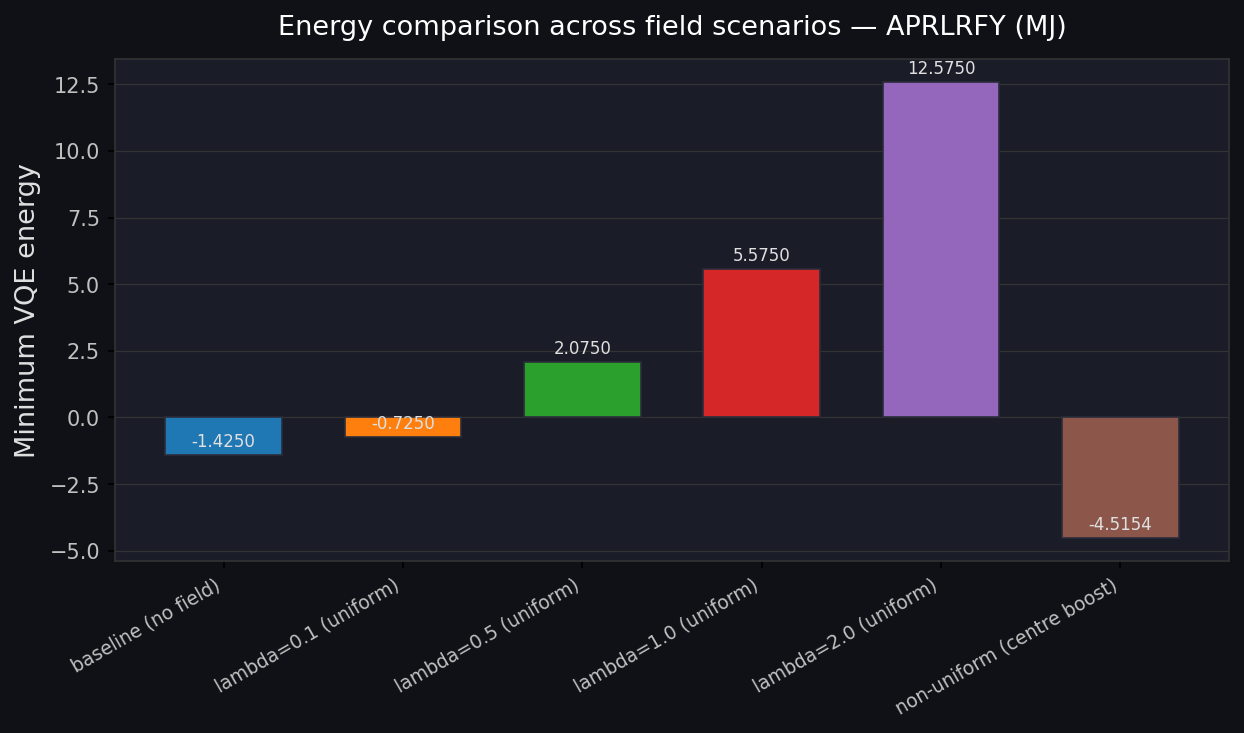


Figure 3: State probability distributions


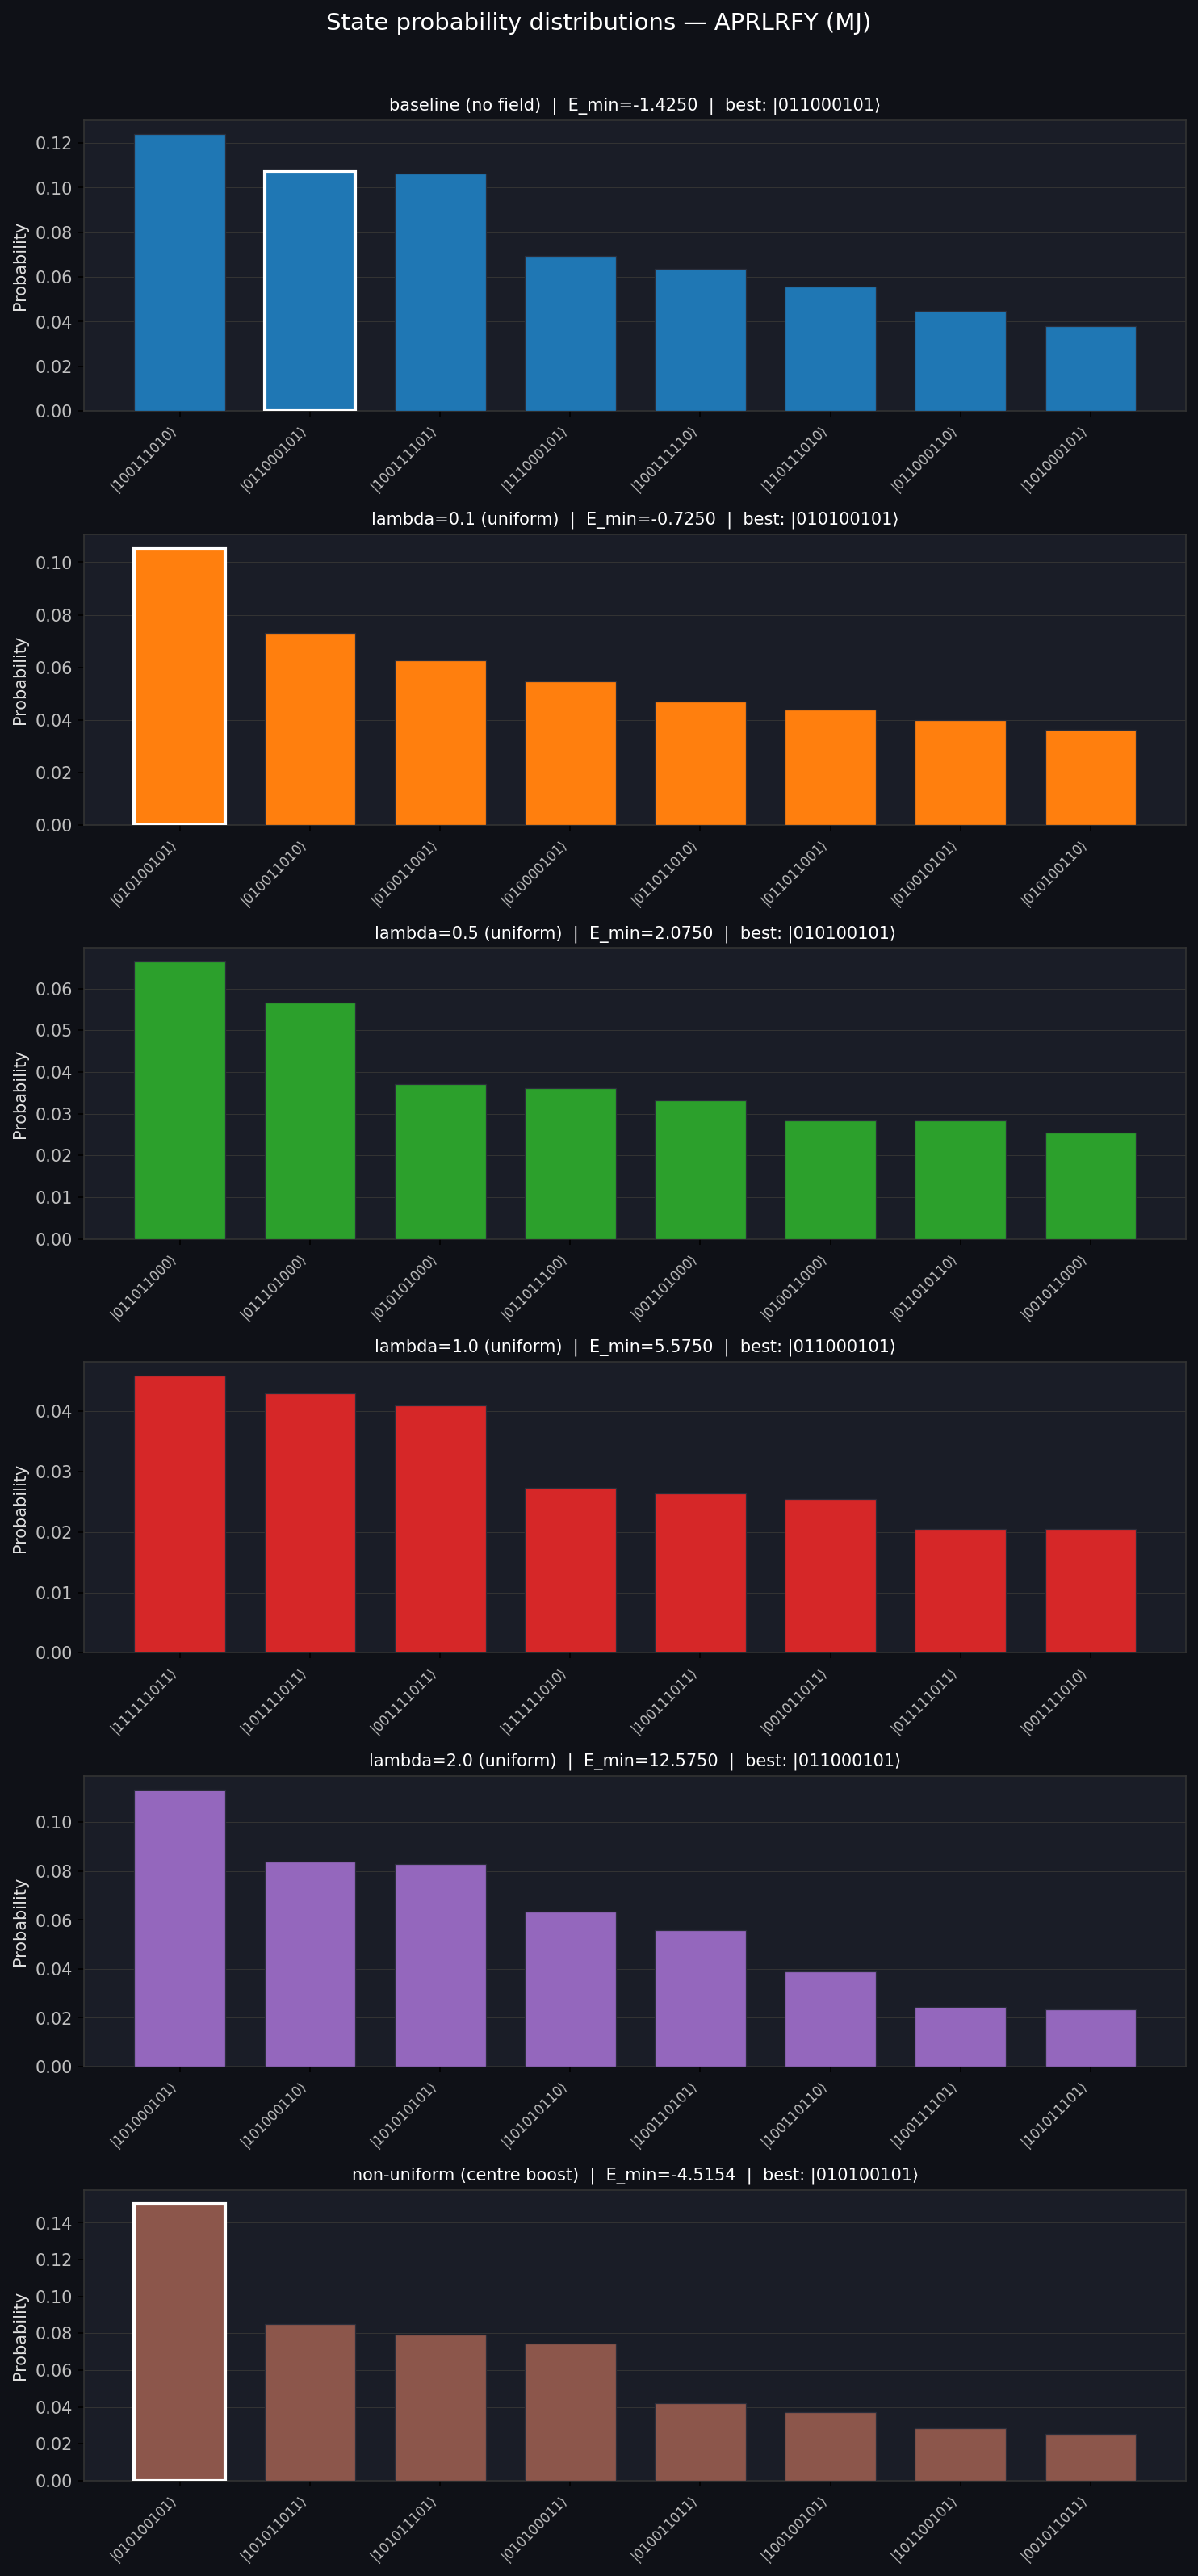

In [7]:
out = Path('plots')
out.mkdir(exist_ok=True)
analysis.plot(output_dir=out)

from IPython.display import Image, display
print('Figure 1: Energy vs. uniform field strength λ')
display(Image(str(out / 'energy_vs_lambda.png')))
print()
print('Figure 2: Energy comparison bar chart')
display(Image(str(out / 'energy_comparison_bar.png')))
print()
print('Figure 3: State probability distributions')
display(Image(str(out / 'probability_distributions.png')))

---
## **Non-Uniform Gaussian Field Profile**

The non-uniform field used in `FieldInfluenceAnalysis._build_non_uniform_field()` follows a **Gaussian bell curve** centred on the chain midpoint:

$$
E_{field}\bigl((i,)\bigr) = \lambda_{max} \cdot \exp\!\left(-\frac{(i - \mu)^2}{\sigma^2}\right)
$$

| Parameter | Value | Meaning |
| :-------- | :---- | :------ |
| $\mu$ | $(N-1)/2$ | Chain midpoint (fractional index) |
| $\sigma$ | $N/4$ | Width; ≈ 2% of peak at termini for typical $N$ |
| $\lambda_{max}$ | $-1.0$ | Peak strength (attractive / stabilising) |

This profile gives **stronger attraction** to central residues (active site analogues) while leaving termini relatively unperturbed.

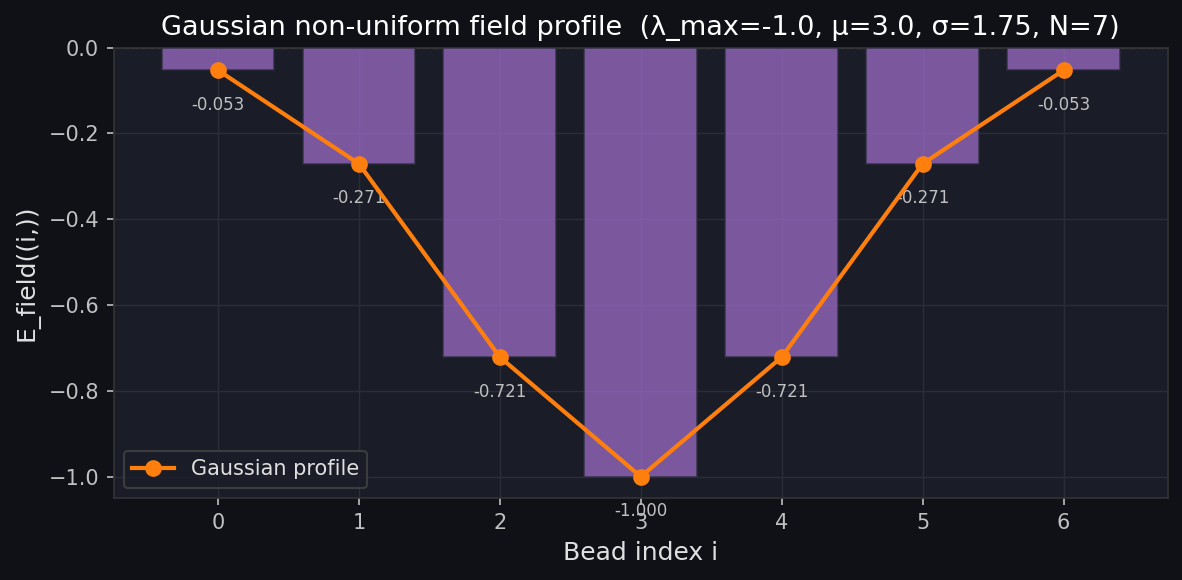

Field values at each bead:
  Bead 0: -0.0529  █
  Bead 1: -0.2709  █████
  Bead 2: -0.7214  ██████████████
  Bead 3: -1.0000  ████████████████████
  Bead 4: -0.7214  ██████████████
  Bead 5: -0.2709  █████
  Bead 6: -0.0529  █


In [8]:
chain_len = 7
mid = (chain_len - 1) / 2
sigma = chain_len / 4
lambda_max = -1.0
bead_indices = np.arange(chain_len)
field_energies = lambda_max * np.exp(-((bead_indices - mid)**2) / sigma**2)

fig, ax = plt.subplots(figsize=(8, 4))
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#1a1d27')
ax.bar(bead_indices, field_energies, color='#9467bd', edgecolor='#2a2d3a',
       linewidth=0.8, zorder=3, alpha=0.8)
ax.plot(bead_indices, field_energies, 'o-', color='#ff7f0e', linewidth=2,
        markersize=7, zorder=4, label='Gaussian profile')
ax.axhline(0, color='#555', linewidth=0.8, linestyle='--')

# Annotate the Gaussian formula
for idx, (xi, yi) in enumerate(zip(bead_indices, field_energies)):
    ax.text(xi, yi - 0.06, f'{yi:.3f}', ha='center', va='top',
            fontsize=8, color='#c0c0c0')

ax.set_xlabel('Bead index i', fontsize=12, color='#e0e0e0')
ax.set_ylabel('E_field((i,))', fontsize=12, color='#e0e0e0')
ax.set_title(
    f'Gaussian non-uniform field profile  '
    f'(λ_max={lambda_max}, μ={mid:.1f}, σ={sigma:.2f}, N={chain_len})',
    fontsize=13, color='#ffffff'
)
ax.tick_params(colors='#c0c0c0')
ax.grid(True, color='#2a2d3a', linewidth=0.7, zorder=0)
ax.spines[:].set_edgecolor('#333')
ax.set_xticks(bead_indices)
ax.legend(fontsize=10, facecolor='#1a1d27', edgecolor='#444', labelcolor='#e0e0e0')
fig.tight_layout()
plt.savefig('plots/gaussian_field_profile.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.close(fig)

display(Image('plots/gaussian_field_profile.png'))
print(f'Field values at each bead:')
for i, e in zip(bead_indices, field_energies):
    bar = '█' * int(abs(e) * 20)
    print(f'  Bead {i}: {e:+.4f}  {bar}')